# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium nr 5

## Temat:
Konwolucyjne sieci neuronowe w zagadnieniu klasyfikacji obrazów I

### Cel ćwiczenia:
Wykorzystanie głębokich sieci neuronowych (MobileNetV2) oraz techniki transfer learningu (zamrażanie warstw i fine-tuning) do klasyfikacji obrazów kwiatów. Zrozumienie wpływu hiperparametrów na proces uczenia oraz analiza wyników za pomocą metryk i macierzy pomyłek.

### Wykorzystane narzędzia:
Python, TensorFlow / Keras, Gradio, Scikit-learn, Matplotlib.

## Zadanie 1: Trening z ustawieniami domyślnymi (5 epok faza 1, 5 epok faza 2)

**Przebieg i wnioski:**
*Zjawisko przeuczenia:* Model nie wykazuje zjawiska przeuczenia w tracie tych 10 epok. Na wykresie Loss widać, że błąd walidacyjny (`val_loss` - pomarańczowa linia) cały czas miarowo i powoli spada, bez jakiejkolwiek tendencji wzrostowej pod koniec, co oznacza, że model stale utrzymuje dobrą zdolność do generalizacji na nowych danych.
*Wpływ fine-tuningu:* Fine-tuning (odmrożenie części warstw bazowych) rozpoczyna się w 6. epoce. Na podanym wykresie dość mocno objawił się on jako krótkotrwały skok do góry błędu treningowego (`loss` - niebieska linia) oraz lekki wpadek dokładności treningowej (`accuracy`). Jednakże, zawirowanie to na danych treningowych zupełnie nie zepsuło wyników walidacyjnych – wręcz przeciwnie, model szybko "ogarnął" odmrożone wagi i pozwoliło to na łagodne obniżanie się `val_loss` do samego końca.

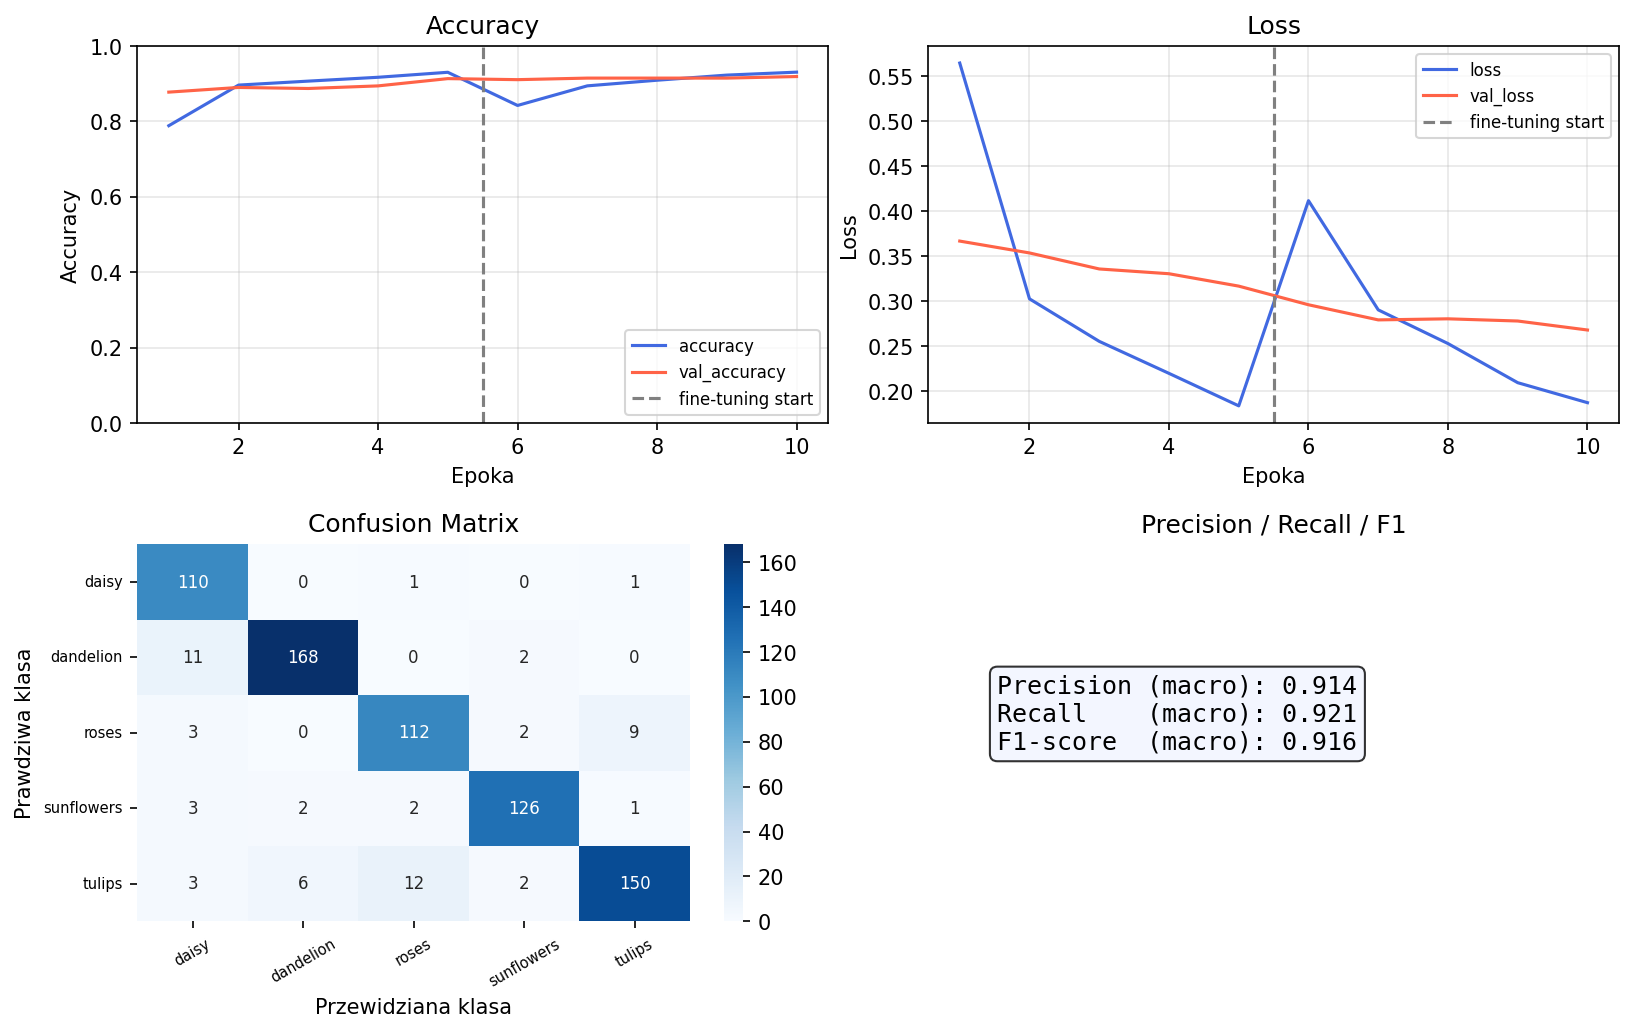

## Zadanie 2: Eksperymenty - 3+3 epoki oraz 10+10 epok

**Wariant A: 3 epoki fazy 1 + 3 epoki fazy 2**
*Wyniki metryk:* Precision: 0.892, Recall: 0.899, F1-score: 0.892.
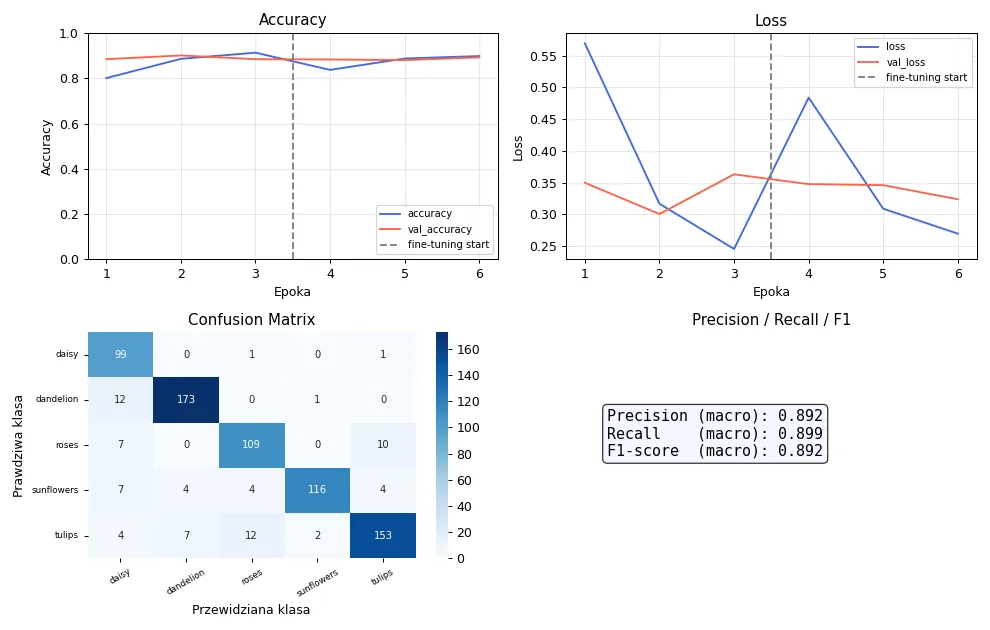

**Wariant B: 10 epok fazy 1 + 10 epok fazy 2**
*Wyniki metryk:* Precision: 0.926, Recall: 0.934, F1-score: 0.928.
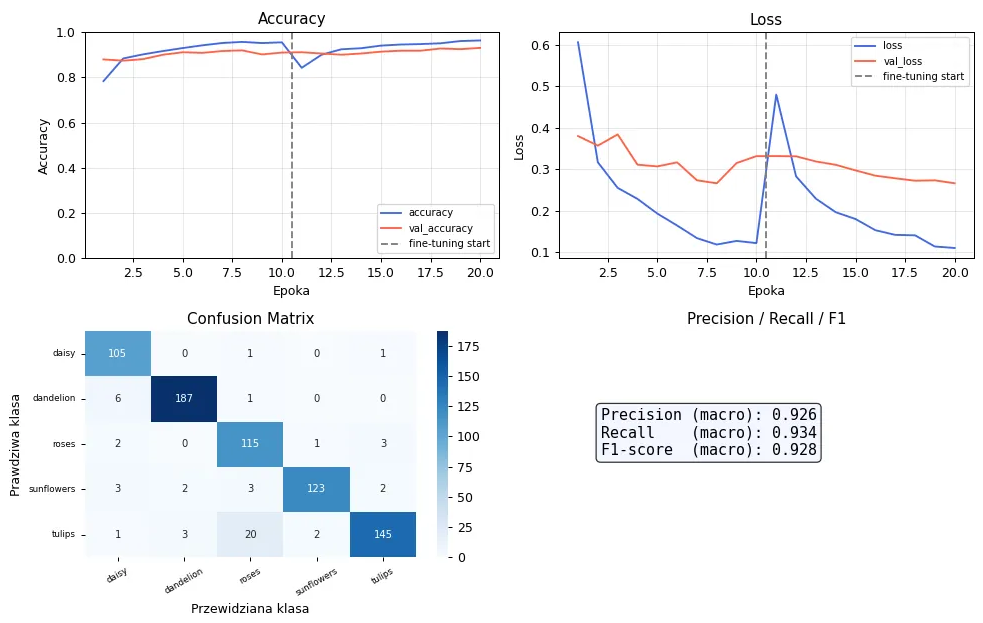

**Porównanie i wnioski wariantu lepszego:**
Wariant 10+10 dał zdecydowanie najlepsze rezultaty pod kątem wszystkich metryk, a w szczególności F1 (osiągając poziom 0.928, w porównaniu z 0.892 dla wariantu 3+3 oraz 0.916 dla domyślnego wariantu 5+5). Wynika to z faktu, że przy jedynie 3 epokach model nie zdążył w pełni zoptymalizować wag przed zakodowaniem wzorców docelowej bazy (podatność na tzw. underfitting). Przeznaczenie 10 epok na każdą z faz dało modelowi odpowiednio dużo czasu na stabilną i głęboką zbieżność, co zaowocowało powolnym, nieustającym zjeżdżaniem błędów walidacyjnych, bez wpadania w widoczne na wykresach drastyczne przeuczenie (błąd walidacyjny na wykresie z 10+10 cały czas malał do bardzo niskiego końcowego poziomu).

## Zadanie 3: Analiza Confusion Matrix

Z załączonej wcześniej Macierzy Pomyłek najczęściej mylonymi obrazami są `tulipany` z `różami` (model przewidział tulipana jako różę 12 razy, a różę jako tulipana wytypował 9 razy). Drugą najczęstszą pomyłką jest rozpoznawanie `mniszka lekarskiego (dandelion)` jako `stokrotki (daisy)` - aż 11 błędnych klasyfikacji w tym polu.
**Hipoteza / Powód błędów:** Obie te pary często dzielą bardzo podobne środowisko, kadr i obrysy. Różowe tulipany i czerwone róże w zamkniętym kadrze mogą mieć dla wczesnych warstw konwolucyjnych podobny, gładki gradient na dużych owalnych płatkach, co gubi sieć. Z kolei stokrotki i mniszki to kwiaty polne fotografowane z podobnej górnej perspektywy często na trawiastym tle – mają identyczną, drobną wielopłatkową budowę okrągłej "korony", co zmyliło model na brak silnych różnic kształtu.

---

## Zadanie 4: Testowanie na zebranych próbkach (klasyfikacja z Sieci)

Zebrano po 2 zdjęcia z klas: `daisy`, `dandelion`, `roses`, `sunflowers`, `tulips` i przetworzono w zakładce *Klasyfikacja obrazu*.

| Zdjęcie | Główna predykcja modelu | Czy zgadł? |
| --- | --- | --- |
| Daisy 1 | daisy | Tak |
| Daisy 2 | daisy | Tak |
| Dandelion 1 | sunflowers | Nie |
| Dandelion 2 | dandelion | Tak |
| Roses 1 | roses | Tak |
| Roses 2 | roses | Tak |
| Sunflowers 1| sunflowers | Tak |
| Sunflowers 2| sunflowers | Tak |
| Tulips 1 | tulips | Tak |
| Tulips 2 | tulips | Tak |

**Własnoręcznie Obliczone Accuracy = 9 / 10 * 100% = 90%**

---

## Zadanie 5: Pytania teoretyczne

**a. Dlaczego zamrażamy bazę w fazie 1?**
Zamrażanie wag (często sieci opartej na konwolucjach bliskich generalnym obrazom np. z ImageNet) zapobiega całkowitemu rozstrojeniu wyuczonych predykatorów. Nowa, losowo zinicjowana końcowa warstwa Dense ma potężne błędy i na początku wywołuje rzędy wielkich gradientów. Gdybyśmy nie zamrozili, te potężne gradienty dotarłyby do wyuczonych cech bazowych niszcząc je całkowicie.

**b. Co daje fine-tuning w fazie 2?**
Kiedy warstwa klasyfikująca (Faza 1) już się ukierunkuje (zacznie stabilnie łapać sygnały po zamrożonym rdzeniu z bardzo małym błędem), odblokowujemy kilka najgłębszych warstw i uczymy na nowo wolnym krokiem bardzo niskim współczynnikiem uczenia (learning_rate np. 1e-5). Pozwala to rdzeniowi na precyzyjne dostrojenie cech specyficznie do datasetu z kwiatami (wzory na płatkach) zamiast używania bazowych struktur np. psów i krzeseł z ImageNet. Prowadzi to do podwyższenia globalnych wskaźników detekcji przez model.

**c. Jaką przewagę ma model wczytany i przetrenowany MobileNetV2 (na ImageNet) nad siecią tworzoną i uczoną od zera na datasecie oxford_flowers102/tf_flowers?**
Tradycyjna sieć wymaga milionów zdjęć, aby wyuczyć w ogóle warstwy rozpoznające takie cechy jak poziome czy pionowe kreski, krzywe gradienty, kontrasty naświetlenia. ImageNet zapewnił MobileNetV2 ten trening, więc transfer-learning pomija setki godzin ukań, jest oporny na przeuczenie (wymaga mniej danych dla domeny docelowej) i prowadzi błyskawicznie do dokładności rzędu ~80-90% nawet przy tak małej grupie danych na CPU w krótkim czasie.

---

## Wnioski Końcowe
Transfer Learning stanowi niebywale skuteczną technikę analizy zjawisk w klasyfikacji obrazu przy drastycznym deficycie siły obliczeniowej lub danych. Sieci potrafią osiągać zaskakującą precyzję, jednak często popadają w zjawisko overfittingu, kiedy zostawiamy je na zbyt wysokiej liczbie epok. 
Warto eksperymentować z epokami i podziałem Faz uczenia w celu wyznaczania optymalnych warunków działania algorytmu dla zadanego zbioru danych.